<a href="https://colab.research.google.com/github/ToshiroHJJZ/Detection-and-Classification-of-Linguistic-Features-for-Effective-Spam-Identification/blob/White-Box-%26-Black-Box-Adversial-Attacks/White_Box_Adversarial_Attack_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# White Box Adversial Attack

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.base import clone

In [ ]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/HThesis/ham_attacked_non_attacked_2.csv", encoding='latin-1')

# Define the spam phrases
spam_phrases = [
    "Make money fast", "Get rich quick", "Financial freedom", "Work from home",
    "Earn thousands daily", "Secret investment", "Guaranteed income",
    "Click here to learn more", "Limited time offer", "Act now!",
    "Shocking", "Secret revealed", "You won't believe", "This is crazy", "One weird trick",
    "Must see", "Viral", "Breaking news", "Exclusive", "Click to find out",
    "Lose weight fast", "Miracle cure", "Instant results", "Burn fat quickly",
    "Boost metabolism", "Detox", "Get ripped", "Weight loss secret", "Magic pill",
    "Free trial", "Meet singles in your area", "Find love now", "Hot girls/guys",
    "Free dating site", "Hookup", "Looking for love", "Find your soulmate",
    "Date tonight", "Single in your city", "Instant connection", "Like and share",
    "Tag a friend", "Follow for more", "Comment below", "Double-tap if you agree",
    "Get more followers", "Go viral", "Get featured", "Free gift", "Limited supply",
    "Discount code", "Best deal ever", "Click here to win", "Free shipping",
    "Money back guarantee", "No risk", "Limited offer", "Once in a lifetime opportunity"
]

# Optimized White-Box Attack Function
def optimized_white_box_attack(text, model, vectorizer, target_label=1):
    """
    Optimized white-box attack function that minimizes redundant computations.
    """
    X_text = vectorizer.transform([text])
    try:
        probabilities = model.predict_proba(X_text)[0][target_label]
    except AttributeError:
        probabilities = 0.5

    gradients = probabilities * X_text.toarray()[0]
    influential_indices = np.argsort(-np.abs(gradients))
    words = text.split()
    feature_names = vectorizer.get_feature_names_out()

    for idx in influential_indices:
        word = feature_names[idx]  # Correctly retrieve the word
        if word in words:
            words[words.index(word)] = random.choice(spam_phrases)
            break

    return ' '.join(words)

# Function to create attacked dataset
def create_attacked_dataset(df, model, vectorizer, attack_function):
    """
    Generates an attacked dataset from the original ham messages.
    """
    ham_df = df[df['label'] == 0].copy()  # Create a copy to avoid modifying the original DataFrame
    new_data = []

    for index, row in ham_df.iterrows():
        original_message = row["text"]
        new_data.append({"text": original_message, "label": 0, "attack_type": "original"})
        attacked_message = attack_function(original_message, model, vectorizer)
        new_data.append({"text": attacked_message, "label": 1, "attack_type": "attacked"})

    attacked_df = pd.DataFrame(new_data)

    # Balance the dataset
    ham_count = attacked_df[attacked_df['label'] == 0].shape[0]
    spam_count = attacked_df[attacked_df['label'] == 1].shape[0]

    if ham_count > spam_count:
        ham_to_remove = ham_count - spam_count
        ham_indices = attacked_df[attacked_df['label'] == 0].index
        remove_indices = np.random.choice(ham_indices, ham_to_remove, replace=False)
        attacked_df = attacked_df.drop(remove_indices)
    elif spam_count > ham_count:
        spam_to_remove = spam_count - ham_count
        spam_indices = attacked_df[attacked_df['label'] == 1].index
        remove_indices = np.random.choice(spam_indices, spam_to_remove, replace=False)
        attacked_df = attacked_df.drop(remove_indices)

    attacked_df = attacked_df.reset_index(drop=True)
    return attacked_df

# Model Training and Evaluation Function
def train_and_evaluate(model, model_name, X_train, X_test, y_train, y_test, vectorizer, attack_function, df):
    """
    Trains the model, generates an attacked dataset, evaluates the model,
    and returns the results.
    """
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Generate attacked dataset
    # Creates and saves attacked dataset (from your code)
    attacked_df = create_attacked_dataset(df, model, vectorizer, optimized_white_box_attack)
    save_path = "/content/drive/MyDrive/HThesis/white_box_attacked_dataset.csv"
    attacked_df.to_csv(save_path, index=False)

    print(f"Attacked dataset saved successfully at: {save_path}")
    X_attacked = vectorizer.transform(attacked_df['text'])
    y_attacked = attacked_df['label']

    # Split the attacked data into training and testing sets
    X_attacked_train, X_attacked_test, y_attacked_train, y_attacked_test = train_test_split(
        X_attacked, y_attacked, test_size=0.2, random_state=42
    )

    # Train the model on the attacked training data
    model.fit(X_attacked_train, y_attacked_train)

    # Evaluate the model on the attacked test data
    y_pred = model.predict(X_attacked_test)

    # Evaluate the model
    accuracy = accuracy_score(y_attacked_test, y_pred)
    report = classification_report(y_attacked_test, y_pred, output_dict=True)

    model_results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Classification Report': report,
        'Training Time': training_time,
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1-score_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1-score_1': report['1']['f1-score']
    }

    return model_results

# 1. Data Preparation
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text data (do this *once*)
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Define Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    #'SVC': SVC(random_state=42, probability=True),
    #'Decision Tree': DecisionTreeClassifier(random_state=42),
    #'Random Forest': RandomForestClassifier(random_state=42),
    #'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    #'Bagging Classifier': BaggingClassifier(DecisionTreeClassifier(random_state=42), random_state=42),
    #'K-Nearest Neighbors': KNeighborsClassifier()
}

# Store results
all_results = []

# Train and Evaluate Models
for model_name, model in models.items():
    print(f"Training and evaluating {model_name}...")

    # Train and evaluate the model, and store the results
    results = train_and_evaluate(clone(model), model_name, X_train_vec, X_test_vec, y_train, y_test, vectorizer, optimized_white_box_attack, df)
    all_results.append(results)

# Print Summary Table
print("\n\nSummary of Model Performances:")
for result in all_results:
    print(f"Model: {result['Model']}")
    print(f"  Accuracy: {result['Accuracy']:.4f}")
    print(f"  Training Time: {result['Training Time']:.4f} seconds")
    print(f"  Precision (Ham): {result['precision_0']:.4f}")
    print(f"  Recall (Ham): {result['recall_0']:.4f}")
    print(f"  F1-Score (Ham): {result['f1-score_0']:.4f}")
    print(f"  Precision (Spam): {result['precision_1']:.4f}")
    print(f"  Recall (Spam): {result['recall_1']:.4f}")
    print(f"  F1-Score (Spam): {result['f1-score_1']:.4f}")
    print("-" * 40)
    created_df = pd.read_csv("/content/drive/MyDrive/HThesis/white_box_attacked_dataset.csv")
    print(f"Dataset shape: {created_df.shape}")
    print("\nClass distribution:")
    print(created_df['label'].value_counts())
    print("\nSample entries:")
    print(created_df.sample(3))


Training and evaluating Logistic Regression...
Attacked dataset saved successfully at: /content/drive/MyDrive/HThesis/white_box_attacked_dataset.csv


Summary of Model Performances:
Model: Logistic Regression
  Accuracy: 0.8570
  Training Time: 0.0386 seconds
  Precision (Ham): 0.8172
  Recall (Ham): 0.9123
  F1-Score (Ham): 0.8621
  Precision (Spam): 0.9050
  Recall (Spam): 0.8039
  F1-Score (Spam): 0.8515
----------------------------------------


FileNotFoundError: [Errno 2] No such file or directory: 'white_box_attacked_dataset.csv'

In [ ]:
!pip install wordcloud
!pip install nltk

In [ ]:
created_df = pd.read_csv("/content/drive/MyDrive/HThesis/white_box_attacked_dataset.csv")

In [ ]:
import nltk # Import the nltk module
from nltk.corpus import wordnet
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# word cloud on text
plt.figure(figsize=(10, 5), facecolor=None)

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [ ]:
# split the data two part label is 0 and 1
ham_df = created_df[created_df['label'] == 0]
spam_df = created_df[created_df['label'] == 1]

In [ ]:
# word cloud on text
from wordcloud import WordCloud
# Filter DataFrame to get ham messages (label 0)
spam_df = created_df[created_df['label'] == 1]

# Now generate the word cloud using the 'text' column of the filtered DataFrame
wordcloud = WordCloud(width=800, height=800,
                      background_color='white',
                      min_font_size=10).generate(" ".join(spam_df['text']))

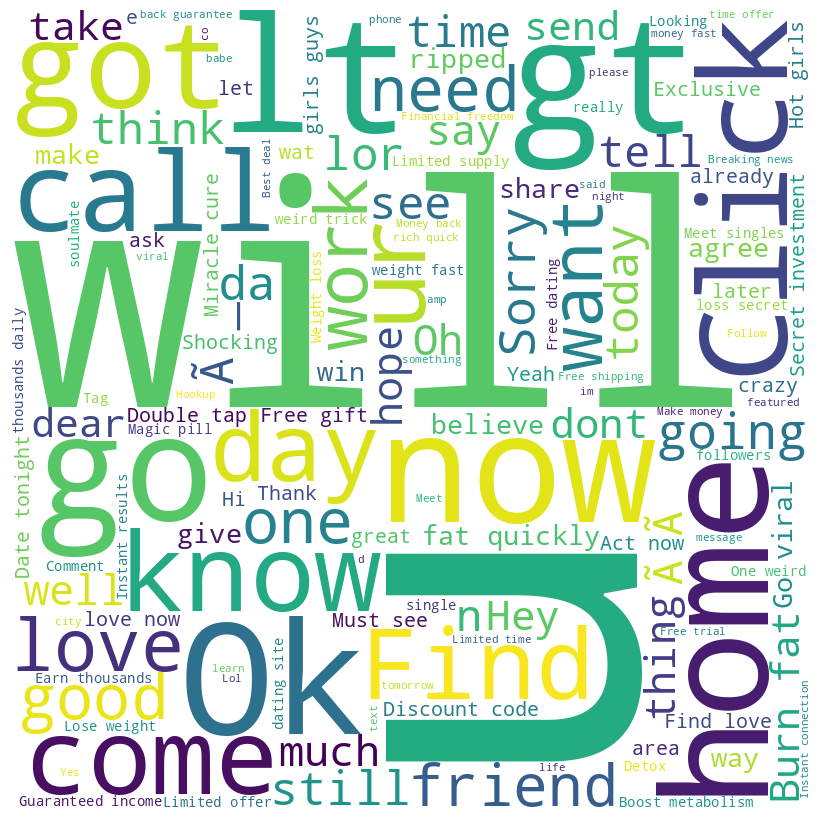

In [ ]:
# plot the word cloud #we are not using word cloud for this EDA, since it is useless.
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

In [ ]:
!pip install textblob nltk # Install necessary libraries
import nltk
nltk.download('vader_lexicon') # Download lexicon for sentiment analysis
from textblob import TextBlob # Import TextBlob
import matplotlib.pyplot as plt # Import Matplotlib for plotting
import pandas as pd # Import pandas for DataFrames

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# Initialize polarities as an empty list to store polarity scores
polarities = []

for index, row in created_df.iterrows(): # Loop through DataFrame
    text = row['text'] # Extract the text from each row
    analysis = TextBlob(text) # Analyze the sentiment of the text
    polarity = analysis.sentiment.polarity # Get polarity score
    polarities.append(polarity) # Append to list

In [ ]:
created_df['polarity'] = polarities # Create new column with polarity values

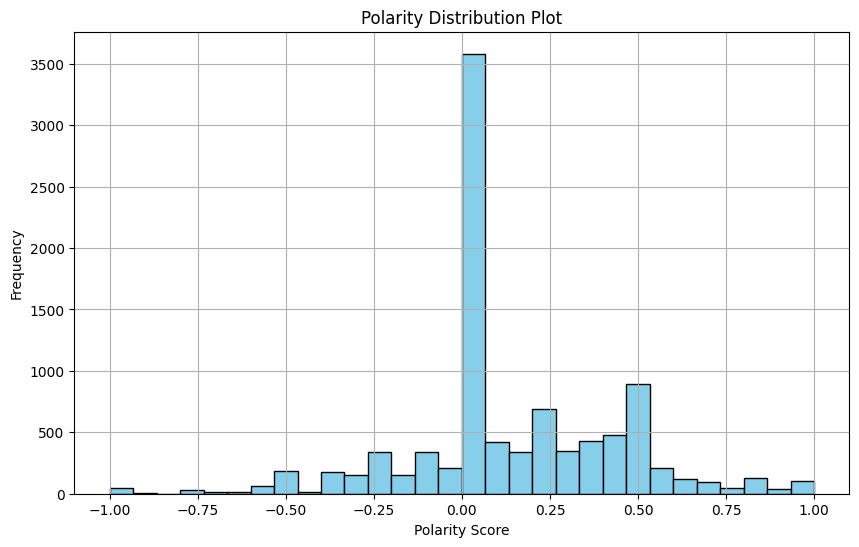

In [ ]:
plt.figure(figsize=(10, 6)) # Create figure with specified size
plt.hist(created_df['polarity'], bins=30, color='skyblue', edgecolor='black') # Histogram
plt.title('Polarity Distribution Plot') # Set title
plt.xlabel('Polarity Score') # Set X-axis label
plt.ylabel('Frequency') # Set Y-axis label
plt.grid(True) # Add grid
plt.show() # Show the plot

In [ ]:
# Basic Metrics
print("\nBasic Metrics:")
print(f"Average Polarity: {created_df['polarity'].mean():.4f}")
print(f"Median Polarity: {created_df['polarity'].median():.4f}")
print(f"Standard Deviation of Polarity: {created_df['polarity'].std():.4f}")
print(f"Minimum Polarity: {created_df['polarity'].min():.4f}")
print(f"Maximum Polarity: {created_df['polarity'].max():.4f}")
print(f"Range of Polarity: {created_df['polarity'].max() - created_df['polarity'].min():.4f}")

# Distribution Metrics
print("\nDistribution Metrics:")
print(f"Number of Positive Scores: {len(created_df[created_df['polarity'] > 0])}")
print(f"Number of Negative Scores: {len(created_df[created_df['polarity'] < 0])}")
print(f"Number of Neutral Scores: {len(created_df[created_df['polarity'] == 0])}")
print(f"Percentage of Positive Scores: {len(created_df[created_df['polarity'] > 0]) / len(created_df) * 100:.2f}%")
print(f"Percentage of Negative Scores: {len(created_df[created_df['polarity'] < 0]) / len(created_df) * 100:.2f}%")
print(f"Percentage of Neutral Scores: {len(created_df[created_df['polarity'] == 0]) / len(created_df) * 100:.2f}%")

# Advanced Metrics
print("\nAdvanced Metrics:")
print(f"Polarity Skewness: {created_df['polarity'].skew():.4f}")
print(f"Polarity Kurtosis: {created_df['polarity'].kurtosis():.4f}")
quantiles = created_df['polarity'].quantile([0.25, 0.5, 0.75])
print(f"Polarity Quantiles (25th, 50th, 75th): {quantiles.values}")
print(f"Polarity Interquartile Range (IQR): {quantiles[0.75] - quantiles[0.25]:.4f}")

# Sentiment Category-based Metrics
print("\nSentiment Category-based Metrics:")
print(f"Average Positive Polarity: {created_df[created_df['polarity'] > 0]['polarity'].mean():.4f}")
print(f"Average Negative Polarity: {created_df[created_df['polarity'] < 0]['polarity'].mean():.4f}")
print(f"Standard Deviation of Positive Polarity: {created_df[created_df['polarity'] > 0]['polarity'].std():.4f}")
print(f"Standard Deviation of Negative Polarity: {created_df[created_df['polarity'] < 0]['polarity'].std():.4f}")


Basic Metrics:
Average Polarity: 0.1256
Median Polarity: 0.0000
Standard Deviation of Polarity: 0.3066
Minimum Polarity: -1.0000
Maximum Polarity: 1.0000
Range of Polarity: 2.0000

Distribution Metrics:
Number of Positive Scores: 4550
Number of Negative Scores: 1737
Number of Neutral Scores: 3363
Percentage of Positive Scores: 47.15%
Percentage of Negative Scores: 18.00%
Percentage of Neutral Scores: 34.85%

Advanced Metrics:
Polarity Skewness: 0.0473
Polarity Kurtosis: 0.9384
Polarity Quantiles (25th, 50th, 75th): [0.   0.   0.35]
Polarity Interquartile Range (IQR): 0.3500

Sentiment Category-based Metrics:
Average Positive Polarity: 0.3725
Average Negative Polarity: -0.2781
Standard Deviation of Positive Polarity: 0.2156
Standard Deviation of Negative Polarity: 0.2169


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Main Values from Histogram of Average Word Length:
Mean: 3.80 Median: 3.75 Standard Deviation: 0.69 Range: 10.50 Interquartile Range (IQR): 0.77 Skewness: 0.92 Kurtosis: 6.02


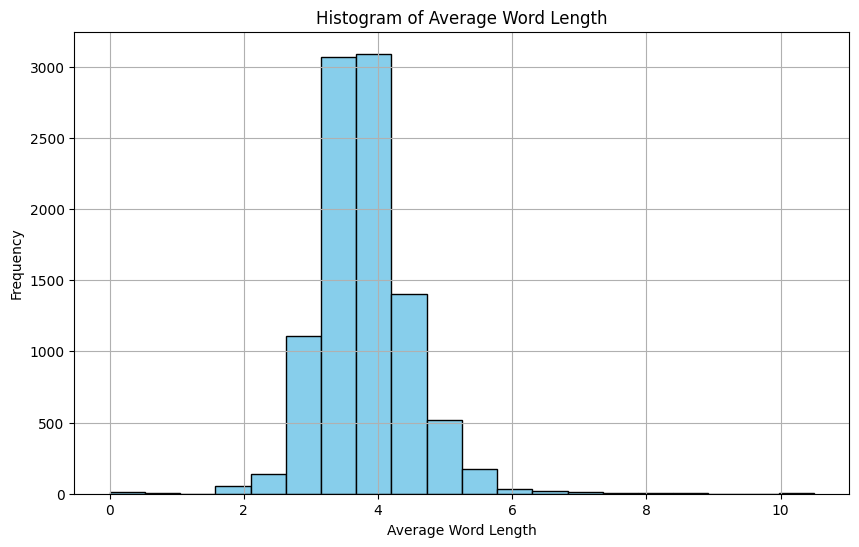

In [ ]:
# Histogram of Average Word Length
from scipy.stats import skew, kurtosis  # Import skew and kurtosis

nltk.download('punkt')

def avg_word_length(text):
  """Calculates the average word length in a given text."""
  words = nltk.word_tokenize(text)
  word_lengths = [len(word) for word in words if word.isalnum()]
  if word_lengths:
    return np.mean(word_lengths)
  else:
    return 0

created_df['avg_word_length'] = created_df['text'].apply(avg_word_length)

# Calculate metrics
mean_word_length = created_df['avg_word_length'].mean()
median_word_length = created_df['avg_word_length'].median()
std_word_length = created_df['avg_word_length'].std()
min_word_length = created_df['avg_word_length'].min()
max_word_length = created_df['avg_word_length'].max()
range_word_length = max_word_length - min_word_length
quantiles = created_df['avg_word_length'].quantile([0.25, 0.5, 0.75])
iqr_word_length = quantiles[0.75] - quantiles[0.25]
skewness_word_length = skew(created_df['avg_word_length'])  # Calculate skewness
kurtosis_word_length = kurtosis(created_df['avg_word_length'])  # Calculate kurtosis


# Print the metrics in the desired format
print("Main Values from Histogram of Average Word Length:")
print(f"Mean: {mean_word_length:.2f} Median: {median_word_length:.2f} "
      f"Standard Deviation: {std_word_length:.2f} Range: {range_word_length:.2f} "
      f"Interquartile Range (IQR): {iqr_word_length:.2f} "
      f"Skewness: {skewness_word_length:.2f} Kurtosis: {kurtosis_word_length:.2f}")

# Create the histogram (optional - you can remove this if not needed)
plt.figure(figsize=(10, 6))
plt.hist(created_df['avg_word_length'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Average Word Length')
plt.xlabel('Average Word Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Main Values from Histogram of Text Length:
Mean: 75.41 Median: 57.00 Standard Deviation: 58.42 Range: 913.00 Interquartile Range (IQR): 59.00 Skewness: 3.32 Kurtosis: 24.46


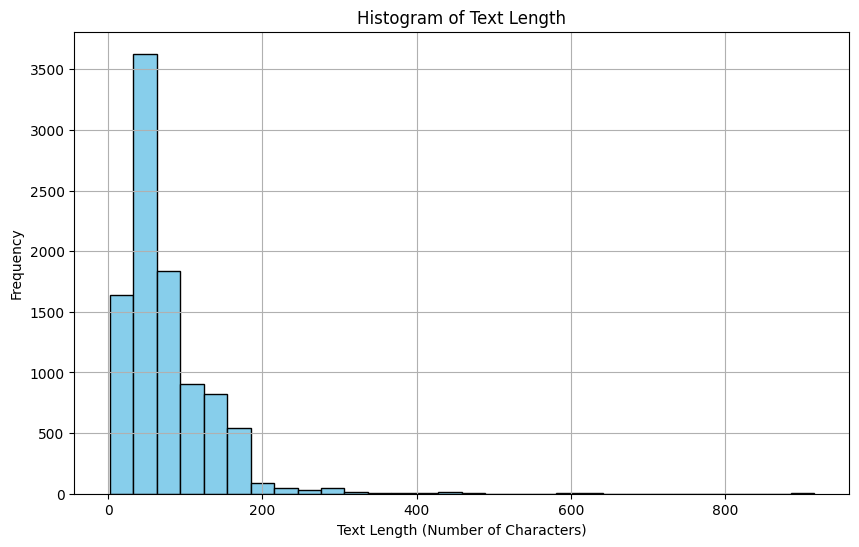

In [ ]:
# Histogram of Text Length

# Calculate text lengths
created_df['text_length'] = created_df['text'].apply(len)

# Calculate metrics
mean_text_length = created_df['text_length'].mean()
median_text_length = created_df['text_length'].median()
std_text_length = created_df['text_length'].std()
min_text_length = created_df['text_length'].min()
max_text_length = created_df['text_length'].max()
range_text_length = max_text_length - min_text_length
quantiles = created_df['text_length'].quantile([0.25, 0.5, 0.75])
iqr_text_length = quantiles[0.75] - quantiles[0.25]
skewness_text_length = skew(created_df['text_length'])
kurtosis_text_length = kurtosis(created_df['text_length'])

# Print the metrics
print("Main Values from Histogram of Text Length:")
print(f"Mean: {mean_text_length:.2f} Median: {median_text_length:.2f} "
      f"Standard Deviation: {std_text_length:.2f} Range: {range_text_length:.2f} "
      f"Interquartile Range (IQR): {iqr_text_length:.2f} "
      f"Skewness: {skewness_text_length:.2f} Kurtosis: {kurtosis_text_length:.2f}")

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(created_df['text_length'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length (Number of Characters)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 10 most common stop words:
i: 5702
you: 3995
to: 3323
a: 2241
the: 2227
in: 1837
and: 1789
is: 1541
me: 1533
my: 1481


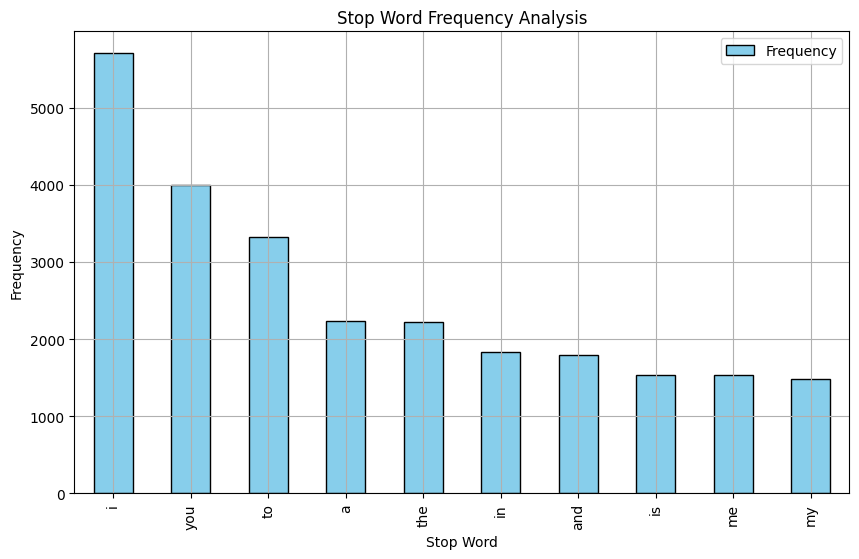

In [ ]:
# Stop Word Frequency Analysis
import nltk
import pandas as pd
from collections import Counter
from nltk.corpus import stopwords

nltk.download('stopwords')

def analyze_stop_word_frequency(df, column_name='text'):
    """
    Analyzes the frequency of stop words in a specified column of a DataFrame.

    Args:
        df: The input DataFrame.
        column_name: The name of the column containing text data (default: 'text').

    Returns:
        A Counter object containing the frequency of each stop word.
    """
    stop_words = set(stopwords.words('english'))  # Get set of English stop words
    all_words = []

    for text in df[column_name]:
        words = nltk.word_tokenize(text)  # Tokenize the text
        all_words.extend([word.lower() for word in words if word.lower() in stop_words])  # Add stop words to the list

    stop_word_counts = Counter(all_words)  # Count the frequency of each stop word
    return stop_word_counts

# Perform stop word frequency analysis
stop_word_counts = analyze_stop_word_frequency(created_df)

# Print the most common stop words
print("Top 10 most common stop words:")
for word, count in stop_word_counts.most_common(10):
    print(f"{word}: {count}")

# Create a bar chart of stop word frequencies
stop_word_df = pd.DataFrame(stop_word_counts.most_common(10), columns=['Stop Word', 'Frequency'])
stop_word_df.plot.bar(x='Stop Word', y='Frequency', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Stop Word Frequency Analysis')
plt.xlabel('Stop Word')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


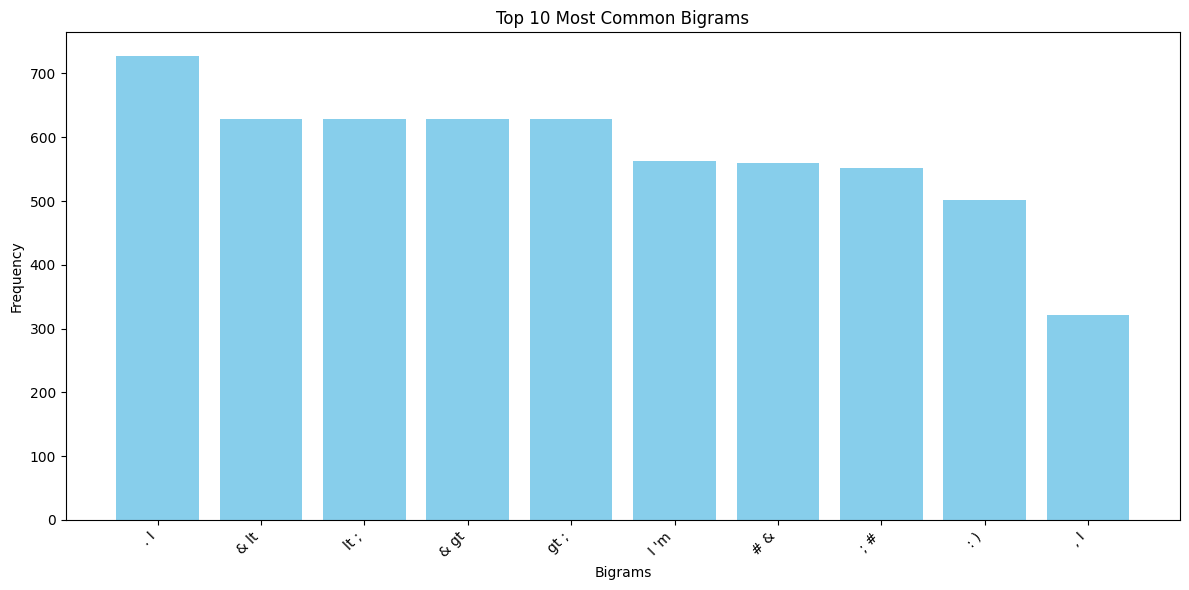

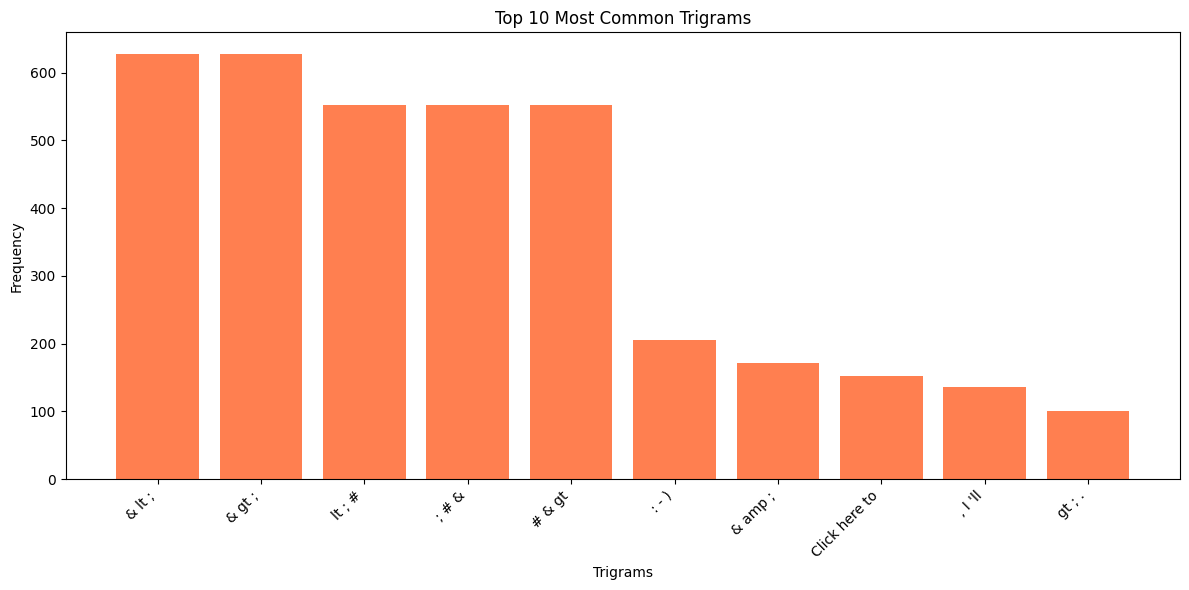

In [ ]:
import nltk
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

nltk.download('punkt')

def generate_ngrams(text, n):
    """
    Generates n-grams from a given text.

    Args:
        text: The input text string.
        n: The value of 'n' for the n-grams (e.g., 2 for bigrams, 3 for trigrams).

    Returns:
        A list of n-grams.
    """
    tokens = nltk.word_tokenize(text)
    ngrams = list(nltk.ngrams(tokens, n))
    return ngrams

def analyze_ngram_frequency(df, column_name='text', n=2):
    """
    Analyzes the frequency of n-grams in a specified column of a DataFrame.

    Args:
        df: The input DataFrame.
        column_name: The name of the column containing text data (default: 'text').
        n: The value of 'n' for the n-grams (default: 2 for bigrams).

    Returns:
        A Counter object containing the frequency of each n-gram.
    """
    all_ngrams = []
    for text in df[column_name]:
        ngrams = generate_ngrams(text, n)
        all_ngrams.extend(ngrams)

    ngram_counts = Counter(all_ngrams)
    return ngram_counts

# Perform bigram (n=2) frequency analysis
bigram_counts = analyze_ngram_frequency(created_df, n=2)

# Get the top 10 most common bigrams
top_bigrams = bigram_counts.most_common(10)

# Create a bar chart for bigrams
plt.figure(figsize=(12, 6))

# Extract bigrams and counts separately
bigrams, counts = zip(*top_bigrams)

# Convert bigrams (tuples) to strings for plotting
bigram_labels = [' '.join(bigram) for bigram in bigrams]

plt.bar(bigram_labels, counts, color='skyblue')
plt.title('Top 10 Most Common Bigrams')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.tight_layout()
plt.show()

# Perform trigram (n=3) frequency analysis
trigram_counts = analyze_ngram_frequency(created_df, n=3)

# Get the top 10 most common trigrams
top_trigrams = trigram_counts.most_common(10)

# Create a bar chart for trigrams
plt.figure(figsize=(12, 6))

# Extract trigrams and counts separately
trigrams, counts = zip(*top_trigrams)

# Convert trigrams (tuples) to strings for plotting
trigram_labels = [' '.join(trigram) for trigram in trigrams]

plt.bar(trigram_labels, counts, color='coral')  # Unpack trigrams and counts
plt.title('Top 10 Most Common Trigrams')
plt.xlabel('Trigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels
plt.tight_layout()
plt.show()

In [ ]:
import nltk
import pandas as pd
from collections import Counter

nltk.download('punkt')

def generate_ngrams(text, n):
    tokens = nltk.word_tokenize(text)
    ngrams = list(nltk.ngrams(tokens, n))
    return ngrams

def analyze_ngram_frequency(df, column_name='text', n=2):
    all_ngrams = []
    for text in df[column_name]:
        ngrams = generate_ngrams(text, n)
        all_ngrams.extend(ngrams)

    ngram_counts = Counter(all_ngrams)
    return ngram_counts

bigram_counts = analyze_ngram_frequency(created_df, n=2)
top_bigrams = bigram_counts.most_common(10)

# Print the bigrams and their counts
print("Top 10 Most Common Bigrams:")
for bigram, count in top_bigrams:
    print(f"{bigram}: {count}")

trigram_counts = analyze_ngram_frequency(created_df, n=3)
top_trigrams = trigram_counts.most_common(10)

# Print the trigrams and their counts
print("\nTop 10 Most Common Trigrams:")
for trigram, count in top_trigrams:
    print(f"{trigram}: {count}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Top 10 Most Common Bigrams:
('.', 'I'): 728
('&', 'lt'): 628
('lt', ';'): 628
('&', 'gt'): 628
('gt', ';'): 628
('I', "'m"): 562
('#', '&'): 560
(';', '#'): 552
(':', ')'): 502
(',', 'I'): 322

Top 10 Most Common Trigrams:
('&', 'lt', ';'): 628
('&', 'gt', ';'): 628
('lt', ';', '#'): 552
(';', '#', '&'): 552
('#', '&', 'gt'): 552
(':', '-', ')'): 206
('&', 'amp', ';'): 172
('Click', 'here', 'to'): 152
(',', 'I', "'ll"): 136
('gt', ';', '.'): 100


The output you're seeing is the result of analyzing the frequency of bigrams (2-word sequences) and trigrams (3-word sequences) in your text data (created_df). The bar charts visually represent these frequencies.
### Bigram Analysis
* ('.', 'I'): This is the most frequent bigram, appearing 728 times. It likely represents the end of a sentence followed by the pronoun "I". This is a very common pattern in natural language.
* ('&', 'lt'), ('lt', ';'), ('&', 'gt'), ('gt', ';'): These bigrams are related to HTML entities or special characters. They might be common if your text data contains HTML markup or encoded text.
* ('I', "'m"): This bigram represents the contraction "I'm" and is another frequent pattern in informal text.
* ('#', '&'), (';', '#'), (':', ')'), (',', 'I'): These bigrams are likely related to punctuation and sentence structure.
* ('&', 'lt', ';'), ('&', 'gt', ';'): These trigrams, like the related bigrams, likely represent HTML entities or special characters.
* ('lt', ';', '#'), (';', '#', '&'), ('#', '&', 'gt'): These trigrams also appear to be related to HTML or encoded text.
* (':', '-', ')'): This trigram likely represents an emoticon or a part of punctuation with a dash.
### Trigram Analysis
* ('&', 'amp', ';'): This trigram is the HTML entity for the ampersand (&) character.
* ('Click', 'here', 'to'): This is a common phrase used in online content and could indicate the presence of links or calls to action in your text data.
* (',', 'I', "'ll"): This trigram represents the phrase ", I'll" and is another frequent pattern in informal writing.
* ('gt', ';', '.'): This trigram might also be related to HTML entities or special characters.
Significance for Adversarial Attack Detection:

HTML/Encoded Text: The frequent occurrence of HTML entities or special characters might be a clue that adversarial attacks are introducing these elements into the text to try to evade detection.
Spammy Phrases: If you see n-grams that are commonly associated with spam or phishing, like "Click here to," "Free offer," or "Make money fast," it could indicate an attack attempt.
Unusual Patterns: Any sudden and significant changes in n-gram frequencies, especially after an attack, should be investigated as they might indicate manipulation of the text.

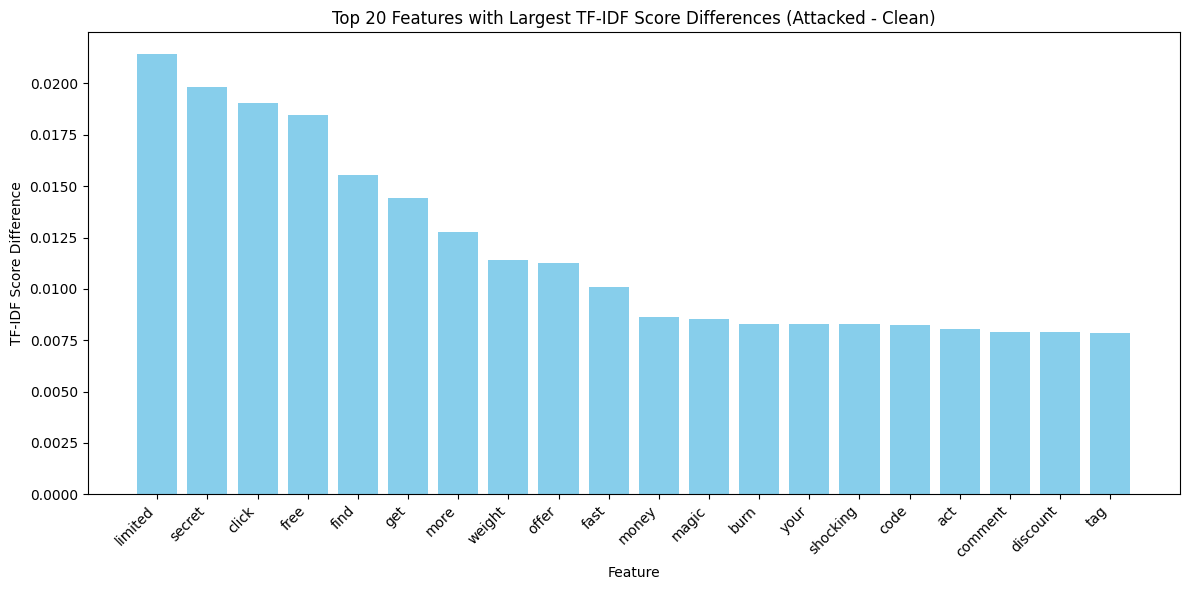

       feature  clean_tfidf  attacked_tfidf  tfidf_diff
3454   limited     0.000120        0.021539    0.021419
5186    secret     0.000247        0.020086    0.019839
1222     click     0.000158        0.019200    0.019042
2346      free     0.003479        0.021946    0.018466
2217      find     0.002420        0.017986    0.015567
2466       get     0.012026        0.026461    0.014434
3867      more     0.003492        0.016281    0.012789
6561    weight     0.000440        0.011863    0.011423
4163     offer     0.000506        0.011751    0.011245
2146      fast     0.000816        0.010926    0.010110
3855     money     0.002783        0.011400    0.008617
3623     magic     0.000063        0.008589    0.008526
956       burn     0.000062        0.008357    0.008296
6824      your     0.014748        0.023034    0.008286
5315  shocking     0.000109        0.008393    0.008284
1253      code     0.000068        0.008310    0.008242
207        act     0.000057        0.008078    0

In [ ]:
# TF-IDF Score Distribution: Examine how term importance
#  shifts between clean and attacked messages.
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Separate clean and attacked messages
clean_messages = created_df[created_df['attack_type'] == 'original']['text']
attacked_messages = created_df[created_df['attack_type'] == 'attacked']['text']

# 2. Create TF-IDF vectors
vectorizer = TfidfVectorizer()
clean_tfidf = vectorizer.fit_transform(clean_messages)
attacked_tfidf = vectorizer.transform(attacked_messages)  # Use the same vocabulary

# 3. Get feature names
feature_names = vectorizer.get_feature_names_out()

# 4. Calculate average TF-IDF scores for each feature
clean_avg_tfidf = clean_tfidf.mean(axis=0).A1  # Convert to 1D array
attacked_avg_tfidf = attacked_tfidf.mean(axis=0).A1

# 5. Create a DataFrame for easier analysis
tfidf_df = pd.DataFrame({'feature': feature_names, 'clean_tfidf': clean_avg_tfidf, 'attacked_tfidf': attacked_avg_tfidf})

# 6. Sort by difference in TF-IDF scores
tfidf_df['tfidf_diff'] = tfidf_df['attacked_tfidf'] - tfidf_df['clean_tfidf']
tfidf_df = tfidf_df.sort_values(by=['tfidf_diff'], ascending=False)

# 7. Visualize the top N features with the largest differences
N = 20  # Number of top features to display
plt.figure(figsize=(12, 6))
plt.bar(tfidf_df['feature'][:N], tfidf_df['tfidf_diff'][:N], color='skyblue')
plt.title(f'Top {N} Features with Largest TF-IDF Score Differences (Attacked - Clean)')
plt.xlabel('Feature')
plt.ylabel('TF-IDF Score Difference')

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')  # Rotate 45 degrees, align to the right

plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()
print(tfidf_df.head(20))

# Here I am just trying some hyperparameters, IT IS NOT PART OF THE CODE.

In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.base import clone

# Load the dataset
df = pd.read_csv("ham_attacked_non_attacked_2.csv", encoding='latin-1')

# Define the spam phrases
spam_phrases = [
    "Make money fast", "Get rich quick", "Financial freedom", "Work from home",
    "Earn thousands daily", "Secret investment", "Guaranteed income",
    "Click here to learn more", "Limited time offer", "Act now!",
    "Shocking", "Secret revealed", "You won't believe", "This is crazy", "One weird trick",
    "Must see", "Viral", "Breaking news", "Exclusive", "Click to find out",
    "Lose weight fast", "Miracle cure", "Instant results", "Burn fat quickly",
    "Boost metabolism", "Detox", "Get ripped", "Weight loss secret", "Magic pill",
    "Free trial", "Meet singles in your area", "Find love now", "Hot girls/guys",
    "Free dating site", "Hookup", "Looking for love", "Find your soulmate",
    "Date tonight", "Single in your city", "Instant connection", "Like and share",
    "Tag a friend", "Follow for more", "Comment below", "Double-tap if you agree",
    "Get more followers", "Go viral", "Get featured", "Free gift", "Limited supply",
    "Discount code", "Best deal ever", "Click here to win", "Free shipping",
    "Money back guarantee", "No risk", "Limited offer", "Once in a lifetime opportunity"
]

# Optimized White-Box Attack Function
def optimized_white_box_attack(text, model, vectorizer, target_label=1):
    """
    Optimized white-box attack function that minimizes redundant computations.
    """
    X_text = vectorizer.transform([text])
    try:
        probabilities = model.predict_proba(X_text)[0][target_label]
    except AttributeError:
        probabilities = 0.5

    gradients = probabilities * X_text.toarray()[0]
    influential_indices = np.argsort(-np.abs(gradients))
    words = text.split()
    feature_names = vectorizer.get_feature_names_out()

    for idx in influential_indices:
        word = feature_names[idx]  # Correctly retrieve the word
        if word in words:
            words[words.index(word)] = random.choice(spam_phrases)
            break

    return ' '.join(words)

# Function to create attacked dataset
def create_attacked_dataset(df, model, vectorizer, attack_function):
    """
    Generates an attacked dataset from the original ham messages.
    """
    ham_df = df[df['label'] == 0].copy()  # Create a copy to avoid modifying the original DataFrame
    new_data = []

    for index, row in ham_df.iterrows():
        original_message = row["text"]
        new_data.append({"text": original_message, "label": 0, "attack_type": "original"})
        attacked_message = attack_function(original_message, model, vectorizer)
        new_data.append({"text": attacked_message, "label": 1, "attack_type": "attacked"})

    attacked_df = pd.DataFrame(new_data)

    # Balance the dataset
    ham_count = attacked_df[attacked_df['label'] == 0].shape[0]
    spam_count = attacked_df[attacked_df['label'] == 1].shape[0]

    if ham_count > spam_count:
        ham_to_remove = ham_count - spam_count
        ham_indices = attacked_df[attacked_df['label'] == 0].index
        remove_indices = np.random.choice(ham_indices, ham_to_remove, replace=False)
        attacked_df = attacked_df.drop(remove_indices)
    elif spam_count > ham_count:
        spam_to_remove = spam_count - ham_count
        spam_indices = attacked_df[attacked_df['label'] == 1].index
        remove_indices = np.random.choice(spam_indices, spam_to_remove, replace=False)
        attacked_df = attacked_df.drop(remove_indices)

    attacked_df = attacked_df.reset_index(drop=True)
    return attacked_df

# Model Training and Evaluation Function
def train_and_evaluate(model, model_name, X_train, X_test, y_train, y_test, vectorizer, attack_function, df):
    """
    Trains the model, generates an attacked dataset, evaluates the model,
    and returns the results.
    """
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Generate attacked dataset
    attacked_df = create_attacked_dataset(df, model, vectorizer, attack_function)
    X_attacked = vectorizer.transform(attacked_df['text'])
    y_attacked = attacked_df['label']

    # Split the attacked data into training and testing sets
    X_attacked_train, X_attacked_test, y_attacked_train, y_attacked_test = train_test_split(
        X_attacked, y_attacked, test_size=0.2, random_state=42
    )

    # Train the model on the attacked training data
    model.fit(X_attacked_train, y_attacked_train)

    # Evaluate the model on the attacked test data
    y_pred = model.predict(X_attacked_test)

    # Evaluate the model
    accuracy = accuracy_score(y_attacked_test, y_pred)
    report = classification_report(y_attacked_test, y_pred, output_dict=True)

    model_results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Classification Report': report,
        'Training Time': training_time,
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1-score_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1-score_1': report['1']['f1-score']
    }

    return model_results

# 1. Data Preparation
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text data (do this *once*)
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Define Models
models = {
    'Logistic Regression': LogisticRegression(max_iter = 100, random_state=42, solver='liblinear'),
    'SVC': SVC(kernel = "rbf", C=1.0, gamma = "scale", random_state=42, probability=True),
    'Decision Tree': DecisionTreeClassifier(criterion = "gini", max_depth = None,random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators = 100, criterion = "gini", max_depth = None, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state=42),
    'Bagging Classifier': BaggingClassifier(estimator = DecisionTreeClassifier(random_state=42),n_estimators = 10,
                                            random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors =5, metric = "minkowski", p=2)
}

# Store results
all_results = []

# Train and Evaluate Models
for model_name, model in models.items():
    print(f"Training and evaluating {model_name}...")

    # Train and evaluate the model, and store the results
    results = train_and_evaluate(clone(model), model_name, X_train_vec, X_test_vec, y_train, y_test, vectorizer, optimized_white_box_attack, df)
    all_results.append(results)

# Print Summary Table
print("\n\nSummary of Model Performances:")
for result in all_results:
    print(f"Model: {result['Model']}")
    print(f"  Accuracy: {result['Accuracy']:.4f}")
    print(f"  Training Time: {result['Training Time']:.4f} seconds")
    print(f"  Precision (Ham): {result['precision_0']:.4f}")
    print(f"  Recall (Ham): {result['recall_0']:.4f}")
    print(f"  F1-Score (Ham): {result['f1-score_0']:.4f}")
    print(f"  Precision (Spam): {result['precision_1']:.4f}")
    print(f"  Recall (Spam): {result['recall_1']:.4f}")
    print(f"  F1-Score (Spam): {result['f1-score_1']:.4f}")
    print("-" * 40)


Training and evaluating Logistic Regression...
Training and evaluating SVC...
Training and evaluating Decision Tree...
Training and evaluating Random Forest...
Training and evaluating Gradient Boosting...
Training and evaluating Bagging Classifier...


C:\Users\jonat\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
C:\Users\jonat\anaconda3\Lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Training and evaluating K-Nearest Neighbors...


Summary of Model Performances:
Model: Logistic Regression
  Accuracy: 0.8513
  Training Time: 0.0816 seconds
  Precision (Ham): 0.8141
  Recall (Ham): 0.9027
  F1-Score (Ham): 0.8561
  Precision (Spam): 0.8956
  Recall (Spam): 0.8018
  F1-Score (Spam): 0.8461
----------------------------------------
Model: SVC
  Accuracy: 0.8275
  Training Time: 48.7463 seconds
  Precision (Ham): 0.7878
  Recall (Ham): 0.8869
  F1-Score (Ham): 0.8344
  Precision (Spam): 0.8763
  Recall (Spam): 0.7703
  F1-Score (Spam): 0.8199
----------------------------------------
Model: Decision Tree
  Accuracy: 0.8078
  Training Time: 0.6582 seconds
  Precision (Ham): 0.7992
  Recall (Ham): 0.8118
  F1-Score (Ham): 0.8055
  Precision (Spam): 0.8163
  Recall (Spam): 0.8039
  F1-Score (Spam): 0.8100
----------------------------------------
Model: Random Forest
  Accuracy: 0.7803
  Training Time: 25.1477 seconds
  Precision (Ham): 0.7881
  Recall (Ham): 0.7548
  F1-Scor

##### Possible idea for White Box, changing the hyper parameters!
* Outcome:
* Highlighted the importance of hyperparameter tuning and adversarial training as defense strategies, but at the cost of baseline comparability.

* Potentially inflated the perceived security of the models, as they are not representative of typical deployment settings.

* Masked the inherent vulnerabilities of the base model architecture.

Therefore it is not worth maximzing the outcome, otherwise it does not look as realistic, we should not be getting such high accuracy levels...

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.base import clone

In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.base import clone

# Load the dataset
# df = pd.read_csv("ham_attacked_non_attacked_2.csv", encoding='latin-1')
df = pd.read_csv("/content/drive/MyDrive/HThesis/ham_attacked_non_attacked_2.csv", encoding='latin-1')

# Define the spam phrases
spam_phrases = [
    "Make money fast", "Get rich quick", "Financial freedom", "Work from home",
    "Earn thousands daily", "Secret investment", "Guaranteed income",
    "Click here to learn more", "Limited time offer", "Act now!",
    "Shocking", "Secret revealed", "You won't believe", "This is crazy", "One weird trick",
    "Must see", "Viral", "Breaking news", "Exclusive", "Click to find out",
    "Lose weight fast", "Miracle cure", "Instant results", "Burn fat quickly",
    "Boost metabolism", "Detox", "Get ripped", "Weight loss secret", "Magic pill",
    "Free trial", "Meet singles in your area", "Find love now", "Hot girls/guys",
    "Free dating site", "Hookup", "Looking for love", "Find your soulmate",
    "Date tonight", "Single in your city", "Instant connection", "Like and share",
    "Tag a friend", "Follow for more", "Comment below", "Double-tap if you agree",
    "Get more followers", "Go viral", "Get featured", "Free gift", "Limited supply",
    "Discount code", "Best deal ever", "Click here to win", "Free shipping",
    "Money back guarantee", "No risk", "Limited offer", "Once in a lifetime opportunity"
]

# Optimized White-Box Attack Function
def optimized_white_box_attack(text, model, vectorizer, target_label=1):
    """
    Optimized white-box attack function that minimizes redundant computations.
    """
    X_text = vectorizer.transform([text])
    try:
        probabilities = model.predict_proba(X_text)[0][target_label]
    except AttributeError:
        probabilities = 0.5

    gradients = probabilities * X_text.toarray()[0]
    influential_indices = np.argsort(-np.abs(gradients))
    words = text.split()
    feature_names = vectorizer.get_feature_names_out()

    for idx in influential_indices:
        word = feature_names[idx]  # Correctly retrieve the word
        if word in words:
            words[words.index(word)] = random.choice(spam_phrases)
            break

    return ' '.join(words)

# Function to create attacked dataset
def create_attacked_dataset(df, model, vectorizer, attack_function):
    """
    Generates an attacked dataset from the original ham messages.
    """
    ham_df = df[df['label'] == 0].copy()  # Create a copy to avoid modifying the original DataFrame
    new_data = []

    for index, row in ham_df.iterrows():
        original_message = row["text"]
        new_data.append({"text": original_message, "label": 0, "attack_type": "original"})
        attacked_message = attack_function(original_message, model, vectorizer)
        new_data.append({"text": attacked_message, "label": 1, "attack_type": "attacked"})

    attacked_df = pd.DataFrame(new_data)

    # Balance the dataset
    ham_count = attacked_df[attacked_df['label'] == 0].shape[0]
    spam_count = attacked_df[attacked_df['label'] == 1].shape[0]

    if ham_count > spam_count:
        ham_to_remove = ham_count - spam_count
        ham_indices = attacked_df[attacked_df['label'] == 0].index
        remove_indices = np.random.choice(ham_indices, ham_to_remove, replace=False)
        attacked_df = attacked_df.drop(remove_indices)
    elif spam_count > ham_count:
        spam_to_remove = spam_count - ham_count
        spam_indices = attacked_df[attacked_df['label'] == 1].index
        remove_indices = np.random.choice(spam_indices, spam_to_remove, replace=False)
        attacked_df = attacked_df.drop(remove_indices)

    attacked_df = attacked_df.reset_index(drop=True)
    return attacked_df

# Model Training and Evaluation Function
def train_and_evaluate(model, model_name, X_train, X_test, y_train, y_test, vectorizer, attack_function, df):
    """
    Trains the model, generates an attacked dataset, evaluates the model,
    and returns the results.
    """
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Generate attacked dataset
    attacked_df = create_attacked_dataset(df, model, vectorizer, attack_function)
    X_attacked = vectorizer.transform(attacked_df['text'])
    y_attacked = attacked_df['label']

    # Split the attacked data into training and testing sets
    X_attacked_train, X_attacked_test, y_attacked_train, y_attacked_test = train_test_split(
        X_attacked, y_attacked, test_size=0.2, random_state=42
    )

    # Train the model on the attacked training data
    model.fit(X_attacked_train, y_attacked_train)

    # Evaluate the model on the attacked test data
    y_pred = model.predict(X_attacked_test)

    # Evaluate the model
    accuracy = accuracy_score(y_attacked_test, y_pred)
    report = classification_report(y_attacked_test, y_pred, output_dict=True)

    model_results = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Classification Report': report,
        'Training Time': training_time,
        'precision_0': report['0']['precision'],
        'recall_0': report['0']['recall'],
        'f1-score_0': report['0']['f1-score'],
        'precision_1': report['1']['precision'],
        'recall_1': report['1']['recall'],
        'f1-score_1': report['1']['f1-score']
    }

    return model_results

# 1. Data Preparation
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize the text data (do this *once*)
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Define Models
models = {
    'Logistic Regression': LogisticRegression(max_iter = 100, random_state=42, solver='lbfgs'),
    'SVC': SVC(kernel = "rbf", C=1.0, gamma = "scale", random_state=42, probability=True),
    'Decision Tree': DecisionTreeClassifier(criterion = "gini", max_depth = None,random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators = 100, criterion = "gini", max_depth = None, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state=42),
    'Bagging Classifier': BaggingClassifier(estimator = DecisionTreeClassifier(random_state=42), n_estimators = 10, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors =5, metric = "minkowski", p=2)
}

# Store results
all_results = []

# Train and Evaluate Models
for model_name, model in models.items():
    print(f"Training and evaluating {model_name}...")

    # Train and evaluate the model, and store the results
    results = train_and_evaluate(clone(model), model_name, X_train_vec, X_test_vec, y_train, y_test, vectorizer, optimized_white_box_attack, df)
    all_results.append(results)

# Print Summary Table
print("\n\nSummary of Model Performances:")
for result in all_results:
    print(f"Model: {result['Model']}")
    print(f"  Accuracy: {result['Accuracy']:.4f}")
    print(f"  Training Time: {result['Training Time']:.4f} seconds")
    print(f"  Precision (Ham): {result['precision_0']:.4f}")
    print(f"  Recall (Ham): {result['recall_0']:.4f}")
    print(f"  F1-Score (Ham): {result['f1-score_0']:.4f}")
    print(f"  Precision (Spam): {result['precision_1']:.4f}")
    print(f"  Recall (Spam): {result['recall_1']:.4f}")
    print(f"  F1-Score (Spam): {result['f1-score_1']:.4f}")
    print("-" * 40)


Training and evaluating Logistic Regression...
Training and evaluating SVC...
Training and evaluating Decision Tree...
Training and evaluating Random Forest...
Training and evaluating Gradient Boosting...
Training and evaluating Bagging Classifier...
Training and evaluating K-Nearest Neighbors...


Summary of Model Performances:
Model: Logistic Regression
  Accuracy: 0.8570
  Training Time: 0.4289 seconds
  Precision (Ham): 0.8160
  Recall (Ham): 0.9144
  F1-Score (Ham): 0.8624
  Precision (Spam): 0.9069
  Recall (Spam): 0.8018
  F1-Score (Spam): 0.8511
----------------------------------------
Model: SVC
  Accuracy: 0.8342
  Training Time: 53.3995 seconds
  Precision (Ham): 0.7914
  Recall (Ham): 0.8985
  F1-Score (Ham): 0.8416
  Precision (Spam): 0.8879
  Recall (Spam): 0.7724
  F1-Score (Spam): 0.8261
----------------------------------------
Model: Decision Tree
  Accuracy: 0.8238
  Training Time: 0.3450 seconds
  Precision (Ham): 0.8183
  Recall (Ham): 0.8235
  F1-Score (Ham): 0.820